Lab 26.1 – Part 1: Data Prep & Modeling
Goal:

Choose a dataset (classification or regression),

Apply preprocessing (imputation, scaling, encoding),

Train at least two baseline models,

Compare performance with hold-out set and CV.

We’ll use the Titanic dataset (classification).

In [1]:
# pip install scikit-learn seaborn pandas numpy matplotlib
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

Load dataset

In [2]:
df = sns.load_dataset("titanic").drop(columns=["alive"])
df = df.copy()
df["survived"] = df["survived"].astype(int)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


2) Define features & split

In [3]:
target = "survived"
features = ['pclass','sex','age','sibsp','parch','fare','embarked','class','who','alone']
 
X = df[features]
y = df[target]
 
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

3) Preprocessing
Separate numeric vs categorical features, and define imputers, scalers, encoders.

In [4]:
num_cols = Xtr.select_dtypes(include="number").columns.tolist()
cat_cols = Xtr.select_dtypes(exclude="number").columns.tolist()
 
numeric_pre = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])
 
categorical_pre = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
 
preprocess = ColumnTransformer([
    ("num", numeric_pre, num_cols),
    ("cat", categorical_pre, cat_cols)
])

4) Baseline models
We’ll compare Logistic Regression and Random Forest.

In [5]:
logreg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])
 
rf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1))
])

5) Fit & evaluate (hold-out)

In [6]:
for name, model in [("LogReg", logreg), ("RandomForest", rf)]:
    model.fit(Xtr, ytr)
    yhat = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    print(f"\n{name} results:")
    print("Acc :", round(accuracy_score(yte, yhat),3))
    print("F1  :", round(f1_score(yte, yhat),3))
    print("ROC :", round(roc_auc_score(yte, proba),3))


LogReg results:
Acc : 0.832
F1  : 0.773
ROC : 0.869

RandomForest results:
Acc : 0.827
F1  : 0.763
ROC : 0.834


6) Cross-validation

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
for name, model in [("LogReg", logreg), ("RandomForest", rf)]:
    scores = cross_validate(model, X, y, cv=cv,
                            scoring={"acc":"accuracy","f1":"f1","roc":"roc_auc"})
    print(f"\n{name} CV mean±std:")
    for m in ["acc","f1","roc"]:
        print(f"{m}: {scores['test_'+m].mean():.3f} ± {scores['test_'+m].std():.3f}")


LogReg CV mean±std:
acc: 0.822 ± 0.007
f1: 0.760 ± 0.014
roc: 0.866 ± 0.022

RandomForest CV mean±std:
acc: 0.817 ± 0.027
f1: 0.759 ± 0.030
roc: 0.872 ± 0.022


7) Visualize feature importances (for tree)

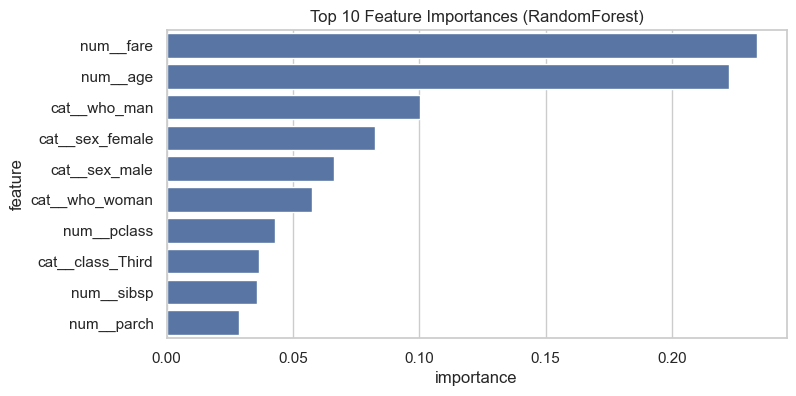

In [8]:
rf.fit(Xtr, ytr)
feat_names = rf.named_steps["prep"].get_feature_names_out()
importances = rf.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature":feat_names, "importance":importances}).sort_values("importance",ascending=False)
 
plt.figure(figsize=(8,4))
sns.barplot(x="importance", y="feature", data=imp_df.head(10))
plt.title("Top 10 Feature Importances (RandomForest)")
plt.show()

Add a third model (e.g., SVC or GradientBoostingClassifier) into the pipeline and compare results.

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

def compare_models_titanic():
    # 1. Load Titanic dataset
    # We use seaborn to load it easily, but you can use pd.read_csv('titanic.csv')
    df = sns.load_dataset('titanic')

    # 2. Select Features and Target
    # We drop 'deck' (too many missing), 'who', 'adult_male' (redundant)
    features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
    X = df[features]
    y = df['survived']

    # 3. Define Preprocessing Steps
    # Numeric: Fill missing values with median, then Scale
    numeric_features = ['age', 'fare', 'sibsp', 'parch']
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Categorical: Fill missing with mode, then OneHotEncode
    categorical_features = ['embarked', 'sex', 'pclass']
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine transformers
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # 4. Define Models to Compare
    classifiers = [
        ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
        ('Random Forest', RandomForestClassifier(random_state=42)),
        ('SVC', SVC(random_state=42)),
        ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
    ]

    # 5. Evaluate
    print(f"{'Model':<25} | {'Accuracy':<10} | {'Std Dev':<10}")
    print("-" * 50)

    results = []

    for name, model in classifiers:
        # Create the full pipeline: Preprocessing -> Classifier
        clf = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

        # 5-fold Cross-Validation
        cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
        
        results.append({
            'Model': name,
            'Accuracy': cv_scores.mean(),
            'Std Dev': cv_scores.std()
        })

        print(f"{name:<25} | {cv_scores.mean():.4f}     | {cv_scores.std():.4f}")

    # 6. Leaderboard
    df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
    print("\nLeaderboard:")
    print(df_results)

if __name__ == "__main__":
    compare_models_titanic()


Model                     | Accuracy   | Std Dev   
--------------------------------------------------
Logistic Regression       | 0.7901     | 0.0216
Random Forest             | 0.8025     | 0.0315
SVC                       | 0.8272     | 0.0168
Gradient Boosting         | 0.8283     | 0.0217

Leaderboard:
                 Model  Accuracy   Std Dev
3    Gradient Boosting  0.828291  0.021718
2                  SVC  0.827161  0.016808
1        Random Forest  0.802517  0.031491
0  Logistic Regression  0.790139  0.021624


Evaluate models with Precision/Recall metrics. Which is more suitable given Titanic’s imbalanced survival rate?

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

def evaluate_precision_recall_titanic():
    # 1. Load Titanic dataset
    df = sns.load_dataset('titanic')

    # 2. Select Features and Target
    features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
    X = df[features]
    y = df['survived']

    # 3. Define Preprocessing Steps
    numeric_features = ['age', 'fare', 'sibsp', 'parch']
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_features = ['embarked', 'sex', 'pclass']
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # 4. Define Models
    classifiers = [
        ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
        ('Random Forest', RandomForestClassifier(random_state=42)),
        ('SVC', SVC(random_state=42)),
        ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
    ]

    # 5. Evaluate with Multiple Metrics
    # We use 'cross_validate' instead of 'cross_val_score' to get multiple metrics at once.
    scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
    
    results = []

    print(f"{'Model':<20} | {'Accuracy':<8} | {'Precision':<9} | {'Recall':<8} | {'F1':<8}")
    print("-" * 65)

    for name, model in classifiers:
        clf = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

        # 5-fold Cross-Validation
        cv_results = cross_validate(clf, X, y, cv=5, scoring=scoring_metrics)
        
        # Calculate means
        acc = cv_results['test_accuracy'].mean()
        prec = cv_results['test_precision'].mean()
        rec = cv_results['test_recall'].mean()
        f1 = cv_results['test_f1'].mean()

        results.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })

        print(f"{name:<20} | {acc:.4f}   | {prec:.4f}    | {rec:.4f}   | {f1:.4f}")

    # 6. Leaderboard sorted by F1 Score (Balanced metric)
    df_results = pd.DataFrame(results).sort_values(by='F1', ascending=False)
    print("\nLeaderboard (Sorted by F1 Score):")
    print(df_results)

if __name__ == "__main__":
    evaluate_precision_recall_titanic()


Model                | Accuracy | Precision | Recall   | F1      
-----------------------------------------------------------------
Logistic Regression  | 0.7901   | 0.7451    | 0.6929   | 0.7170
Random Forest        | 0.8025   | 0.7533    | 0.7221   | 0.7361
SVC                  | 0.8272   | 0.8172    | 0.7103   | 0.7584
Gradient Boosting    | 0.8283   | 0.8144    | 0.7162   | 0.7608

Leaderboard (Sorted by F1 Score):
                 Model  Accuracy  Precision    Recall        F1
3    Gradient Boosting  0.828291   0.814379  0.716155  0.760778
2                  SVC  0.827161   0.817213  0.710273  0.758412
1        Random Forest  0.802517   0.753271  0.722080  0.736085
0  Logistic Regression  0.790139   0.745071  0.692882  0.716955
